# ChaRT

This notebook combines the

- `prep_chart`
- `run_chart`
- `intro_chart_data`
- `max`
- `psf_image`

threads into one.

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 942
download_chandra_obsid 942

chandra_repro 942 out=`pwd` clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  233.9 kb/s
  oif      fits       25 Kb  ####################          < 1 s  688.6 kb/s
  vv       pdf        44 Kb  ####################          < 1 s  1688.9 kb/s
  cntr_img fits      174 Kb  ####################          < 1 s  6580.8 kb/s
  cntr_img jpg       820 Kb  ####################          < 1 s  10099.0 kb/s
  evt2     fits       18 Mb  ####################          < 1 s  37450.8 kb/s
  full_img fits       86 Kb  ####################          < 1 s  3046.5 kb/s
  full_img jpg        70 Kb  ####################          < 1 s  6648.6 kb/s
  bpix     fits       39 Kb  ####################          < 1 s  1563.8 kb/s
  fov      fits        6 Kb  ####################          < 1 s  880.2 kb/s
  eph1     fits      281 Kb  ####################          < 1 s

In [3]:
ra="12:16:56.990"
dec="+37:43:35.69"
myid=`date +%s`

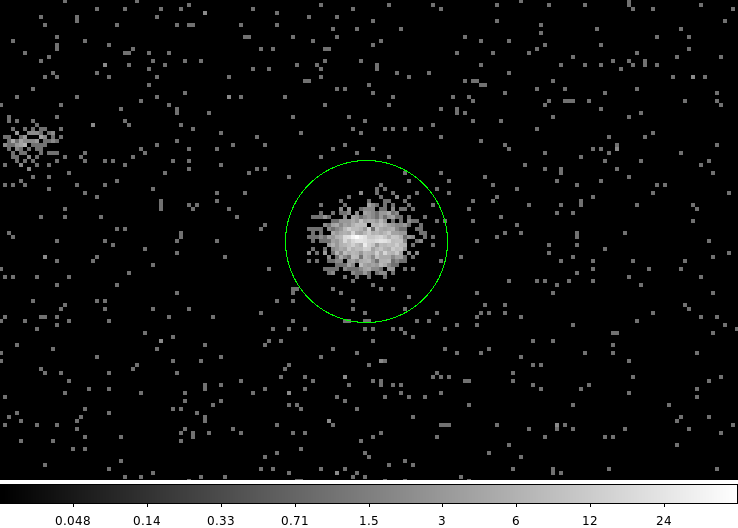

In [4]:
ds9 acisf00942_repro_evt2.fits \
  -scale log \
  -regions command "fk5;circle(${ra},${dec},0.1667')" \
  -pan to ${ra} ${dec} fk5 \
  -bin factor 1 -zoom 4 \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

### detect coords


In [5]:
punlearn dmcoords
dmcoords acisf00942_repro_evt2.fits op=cel ra=${ra} dec=${dec} celfmt=hms
pget dmcoords theta phi

5.975230555172388
197.8625696580994


## Spectral Shape

### Upload file

In [6]:
specextract "acisf00942_repro_evt2.fits[sky=circle(${ra},${dec},20)]" ngc4244 clob+

Running specextract
Version: 30 November 2016

Using event file acisf00942_repro_evt2.fits[sky=circle(12:16:56.990,+37:43:35.69,20)]

Aspect solution file pcadf075214790N004_asol1.fits found.

Bad-pixel file acisf00942_repro_bpix1.fits found.

Mask file acisf00942_001N004_msk1.fits found.

Setting bad pixel file 

Extracting src spectra 

Creating src ARF 

Creating src RMF 

Using mkacisrmf...

Grouping src spectrum 

Updating header of ngc4244.pi with RESPFILE and ANCRFILE keywords.

Updating header of ngc4244_grp.pi with RESPFILE and ANCRFILE keywords.



read ARF file ngc4244.arf
read RMF file ngc4244.rmf
Dataset               = 1
Method                = levmar
Statistic             = chi2gehrels
Initial fit statistic = 29286.3
Final fit statistic   = 74.2295 at function evaluation 66
Data points           = 93
Degrees of freedom    = 90
Probability [Q-value] = 0.88525
Reduced statistic     = 0.824772
Change in statistic   = 29212
   abs1.nH        0.415771    
   p1.gamma       5.00418     
   p1.ampl        0.000334406 
Created: 1485348855.dat


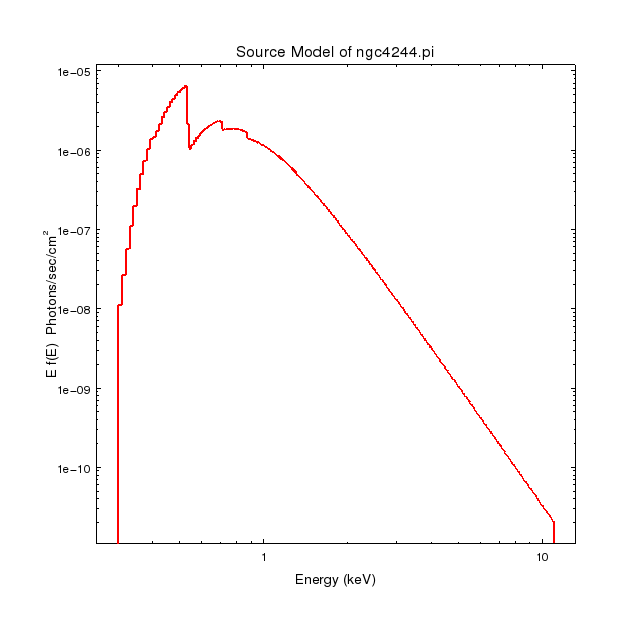

In [7]:
cat << EOM > s1.py
load_data("ngc4244.pi")
group_counts(10)
notice(0.4,6.0)
set_source( xsphabs.abs1 * powlaw1d.p1)
abs1.nh = 0.5
guess(p1)
fit()
set_analysis(1, "energy", "rate", factor=1)
plot_source()
log_scale(XY_AXIS)
print_window("sherpa_01.png","export.clobber=True")

from sherpa_contrib.chart import *
save_chart_spectrum("${myid}.dat", elow=0.4, ehigh=6.0)


quit()
EOM

sherpa -n s1.py
display < sherpa_01.png 

In [8]:
dmlist ${myid}.dat cols

 
--------------------------------------------------------------------------------
Columns for Table Block 1485348855.dat
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   elo                               Real8          -Inf:+Inf            
   2   ehi                               Real8          -Inf:+Inf            
   3   spectrum                          Real8          -Inf:+Inf            


### Monochromatic energy

In [9]:
srcflux acisf00942_repro_evt2.fits "${ra} ${dec}" flux psfmethod=quick verbose=0 clob+
dmkeypar flux_broad.flux net_photflux_aper echo+        

0.000169243804481731


## Aspect Information

### Specify OBS_ID value

In [10]:
dmkeypar acisf00942_repro_evt2.fits OBS_ID echo+

942


In [11]:
dmkeypar acisf00942_repro_evt2.fits OBI_NUM echo+

1


### Upload asol file

In [12]:
echo "DATE-OBS calcForce" > hdr_lookup.txt
echo "DATE-END calcForce" >> hdr_lookup.txt
echo "TSTART calcForce" >> hdr_lookup.txt
echo "TSTOP calcForce" >> hdr_lookup.txt
dmmerge @acisf00942_asol1.lis pcad_asol.fits lookupTab=hdr_lookup.txt clob+

### No dither

In [13]:
dmlist acisf00942_repro_evt2.fits header,clean | grep _NOM

RA_NOM                     184.3430399825 [deg]     Nominal RA
DEC_NOM                     37.7808853898 [deg]     Nominal Dec
ROLL_NOM                   230.8753656982 [deg]     Nominal Roll


In [14]:
dmmakepar acisf00942_repro_evt2.fits hdr.par clob+
grep _nom hdr.par

ra_nom,r,h,184.3430399825,,,"Nominal RA [deg]"
dec_nom,r,h,37.780885389847,,,"Nominal Dec [deg]"
roll_nom,r,h,230.87536569819,,,"Nominal Roll [deg]"


## Run CHaRT

In [15]:

curl \
  -F email=${USER}@head.cfa.harvard.edu \
  -F coords=cel \
  -F ra=${ra} \
  -F dec=${dec} \
  -F asol=obi \
  -F obsid=942 \
  -F obinum=1\
  -F niter=10\
  -F randseed=32767 \
  -F energy=upload_spectrum \
  -F spectrum=@${myid}.dat \
  http://saotrace.cfa.harvard.edu/cgi-bin/runwrapper


    <html>
    <head><title>ChaRT Job Submitted</title></head>
    <body>
        <h1>ChaRT v2</h1>
    Job submitted.  You will recieve an email from cxc_rays@head.cfa.harvard.edu when the job is complete or if there are any errors.
    </body>
    </html>


In [16]:
sleep 10
max_tries=10
try=1

get_cmd="curl -s -O ftp://saotrace.cfa.harvard.edu/pub/ChaRT/HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered.tar.gz"
echo $get_cmd

$get_cmd
stt=$?
while test $stt -ne 0 -a $try -le $max_tries
do
  echo Attempt $try of $max_tries
  sleep 10
  try=`echo $try + 1| bc `
  $get_cmd
  stt=$?  
done

if test $stt -ne 0
then
  echo ChaRT Timed Out
fi




curl -s -O ftp://saotrace.cfa.harvard.edu/pub/ChaRT/HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered.tar.gz
Attempt 1 of 10
Attempt 2 of 10
Attempt 3 of 10


## Download, intro_data_chart

In [17]:
tar xvfz HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered.tar.gz

HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0004_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0008_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0009_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0001_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0007_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0005_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0002_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0006_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0003_rays.fits
HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0000_rays.fits


In [18]:
dmlist HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i0000_rays.fits cols

 
--------------------------------------------------------------------------------
Columns for Table Block PSFRAYS
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   rt_cosx              none         Real8          -0.99955862918341:   -0.99664025395524 Label for field
   2   rt_cosy              none         Real8          -0.08131823502927:    0.06246696829001 Label for field
   3   rt_cosz              none         Real8          -0.06217273435219:    0.06132158824706 Label for field
   4   rt_kev               KeV          Real8          0.40001209364319:        5.8122639775 Label for field
   5   rt_x                 mm           Real8          -10079.770:   -10079.770 Label for field
   6   rt_y                 mm           Real8          -412.3348096384:       28.8498576412 Label for field
   7   rt_z                 mm           Real8          -44.1509405039:      348.225442183

In [19]:
dmlist HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i0000_rays.fits header

 
--------------------------------------------------------------------------------
Header keys for block PSFRAYS
--------------------------------------------------------------------------------
 
 --  COMMENT              This FITS file may contain long string keyword values that are
 --  COMMENT              continued over multiple keywords.  This convention uses the  '&'
 --  COMMENT              character at the end of a string which is then continued
 --  COMMENT              on subsequent keywords whose name = 'CONTINUE'.
0001 SRFNO                2                              Int4         
0002 SRC_E                INDEF [keV]                    String       Energy used to generate rays
0003 SRC_DENS             0 [r/mm^2]                     Int4         Ray density
0004 SRC_FLUX             INDEF                          String       Source flux
0005 SRC_SPEC             1485348855.dat                 String       Spectrum used to generate rays
0006 SRC_EXPT                 50

In [60]:
dmlist "HRMA_ra184.23746_dec37.72658_${myid}.dat*_rays.fits" header | grep PSFSEED2

0016 PSFSEED2             32767                          Int4         Secondary random seed
0016 PSFSEED2             32768                          Int4         Secondary random seed
0016 PSFSEED2             32770                          Int4         Secondary random seed
0016 PSFSEED2             32773                          Int4         Secondary random seed
0016 PSFSEED2             32777                          Int4         Secondary random seed
0016 PSFSEED2             32782                          Int4         Secondary random seed
0016 PSFSEED2             32788                          Int4         Secondary random seed
0016 PSFSEED2             32795                          Int4         Secondary random seed
0016 PSFSEED2             32803                          Int4         Secondary random seed
0016 PSFSEED2             32812                          Int4         Secondary random seed


In [61]:
dmlist "HRMA_ra184.23746_dec37.72658_${myid}.dat*_rays.fits" counts

8462    
8445    
8318    
8483    
8306    
8435    
8559    
8417    
8381    
8441    


## Run MARX

### Install MARX

In [22]:
if test x`uname` = xDarwin
then
  export CC=/opt/local/bin/gcc
fi


echo | install_marx  `pwd` < /dev/null 

Installing MARX 5.3.2 into /data/sdsreg/thread_output/CIAO4.9/prep_chart

If this is not where you want it installed, please
press Control+C to exit and specify the directory.

Press Enter to continue
--2017-01-25 07:56:32--  ftp://space.mit.edu/pub/cxc/marx/v5.3/marx-dist-5.3.2.tar.gz
           => `marx-dist-5.3.2.tar.gz'
Resolving space.mit.edu... 18.75.0.10
Connecting to space.mit.edu|18.75.0.10|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /pub/cxc/marx/v5.3 ... done.
==> SIZE marx-dist-5.3.2.tar.gz ... 13500024
==> PASV ... done.    ==> RETR marx-dist-5.3.2.tar.gz ... done.
Length: 13500024 (13M) (unauthoritative)

100%[======================================>] 13,500,024  4.87M/s   in 2.6s    

2017-01-25 07:56:35 (4.87 MB/s) - `marx-dist-5.3.2.tar.gz' saved [13500024]

checking for gcc... gcc
checking whether the C compiler works... yes
checking for C compiler default output file name... a.out
c

In [23]:
source ./marx-5.3.2/setup_marx.sh

### Get coords

In [24]:
dmlist acisf00942_repro_evt2.fits header | grep _NOM

0056 RA_NOM                     184.3430399825 [deg]     Real8        Nominal RA
0057 DEC_NOM                     37.7808853898 [deg]     Real8        Nominal Dec
0058 ROLL_NOM                   230.8753656982 [deg]     Real8        Nominal Roll


In [25]:
dra=`dmkeypar HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i0000_rays.fits SRC_RA echo+`
echo $dra

184.237458333


In [26]:
ddec=`dmkeypar HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i0000_rays.fits SRC_DEC echo+`
echo $ddec

37.7265805556


In [27]:
dmkeypar HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i0000_rays.fits ASOLFILE echo+

pcadf075214790N004_asol1.fits


### Run simulate_psf

In [28]:
pset simulate_psf infile=acisf00942_repro_evt2.fits 
pset simulate_psf outroot=chart
pset simulate_psf ra=$dra
pset simulate_psf dec=$ddec
pset simulate_psf simulator=file
pset simulate_psf rayfile=HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i0000_rays.fits
pset simulate_psf projector=marx
pset simulate_psf random_seed=34455
simulate_psf mode=h

simulate_psf
          infile = acisf00942_repro_evt2.fits
         outroot = chart
              ra = 184.237458333
             dec = 37.7265805556
    spectrumfile = 
      monoenergy = INDEF
            flux = INDEF
       simulator = file
         rayfile = HRMA_ra184.23746_dec37.72658_1485348855.dat_dithered_i0000_rays.fits
       projector = marx
     random_seed = -1
            blur = 0.07000000000000001
  readout_streak = no
          pileup = no
           ideal = yes
        extended = yes
         binsize = 1
          numsig = 7
         minsize = INDEF
         numiter = 1
        keepiter = no
        asolfile = 
       marx_root = /data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2
         verbose = 1
            mode = h

Started check_setup
Finished check_setup
Performing iteration 1 of 1
Started run_marx
Finished run_marx
Started create_psf_image
Finished create_psf_image
Started create_average_image
Finished create_average_image

Final output PSF image is : c

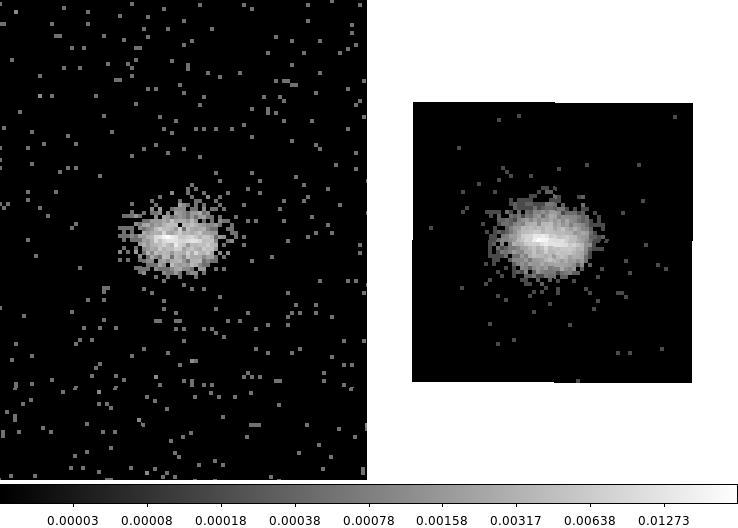

In [29]:
ds9 acisf00942_repro_evt2.fits \
  -scale log \
  -pan to ${ra} ${dec} fk5 \
  -bin factor 1 -zoom 4 \
  chart.psf -scale log \
  -match frame wcs \
  -saveimage png ds9_02.png -quit

display < ds9_02.png 


### Combine all iterations

In [30]:
/bin/ls -1 HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i*_rays.fits > rays.lis

pset simulate_psf outroot=chart_coadd
pset simulate_psf rayfile=@rays.lis
simulate_psf mode=h

simulate_psf
          infile = acisf00942_repro_evt2.fits
         outroot = chart_coadd
              ra = 184.237458333
             dec = 37.7265805556
    spectrumfile = 
      monoenergy = INDEF
            flux = INDEF
       simulator = file
         rayfile = @rays.lis
       projector = marx
     random_seed = -1
            blur = 0.07000000000000001
  readout_streak = no
          pileup = no
           ideal = yes
        extended = yes
         binsize = 1
          numsig = 7
         minsize = INDEF
         numiter = 1
        keepiter = no
        asolfile = 
       marx_root = /data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2
         verbose = 1
            mode = h

Started check_setup
Finished check_setup
10 rayfiles provided; ignoring numiter=1 parameter
Performing iteration 1 of 10
Started run_marx
Finished run_marx
Started create_psf_image
Finished create_psf_image
Performing iteration 2 of 10
Started run_marx
Finished run_marx
Started create_psf_image
F

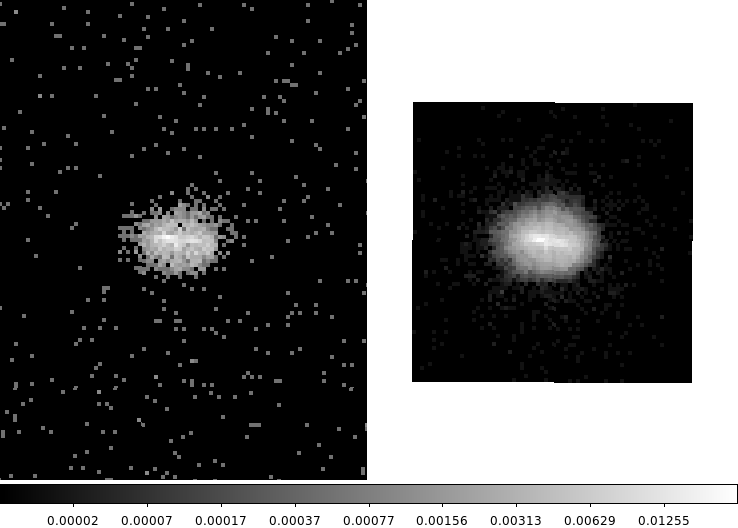

In [31]:
ds9 acisf00942_repro_evt2.fits \
  -scale log \
  -pan to ${ra} ${dec} fk5 \
  -bin factor 1 -zoom 4 \
  chart_coadd.psf -scale log \
  -match frame wcs \
  -saveimage png ds9_03.png -quit

display < ds9_03.png 


---
## Step By Step


In [32]:
cp -fv $MARX_ROOT/share/marx/pfiles/marx.par ./marx.par
chmod +w ./marx.par

`/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/pfiles/marx.par' -> `./marx.par'


In [33]:
pset ./marx SAOSACFile=HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i0000_rays.fits
pset ./marx OutputDir=marx_output_i0000.dir
pset ./marx SourceType=SAOSAC

pset ./marx RA_Nom=184.34304
pset ./marx Dec_Nom=37.78089
pset ./marx Roll_Nom=230.87537
pset ./marx SourceRA=184.237458333
pset ./marx SourceDEC=37.7265805556

pset ./marx DitherModel=FILE
pset ./marx DitherFile=pcadf075214790N004_asol1.fits

pset ./marx DetectorType=ACIS-S 
pset ./marx GratingType=NONE
pset ./marx ExposureTime=0.0

In [34]:
dmlist acisf00942_repro_evt2.fits header | grep SIM_

0040 SIM_X                   -0.68282252473119 [mm]      Real8        SIM focus pos
0041 SIM_Y                                   0 [mm]      Real8        SIM orthogonal axis pos
0042 SIM_Z                     -190.1400660499 [mm]      Real8        SIM translation stage pos


In [35]:
pset ./marx DetOffsetX=0.00144494
pset ./marx DetOffsetY=0
pset ./marx DetOffsetZ=-0.00754295

In [36]:
pset ./marx AspectBlur=0.25

In [37]:
marx @@./marx.par

MARX version 5.3.2, Copyright (C) 2002-2016 Massachusetts Institute of Technology

	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/EKCHDOS06.rdb
Reading binary HRMA optical constants:
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/iridium.dat
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/corr_1.dat
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/corr_3.dat
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/corr_4.dat
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/corr_6.dat
Reading scattering tables
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/scat_p1_M.bin
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/scat_h1_M.bin
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/scat_p3_M.bin
	/data/sdsreg/thread_output/C

In [38]:
ls marx_output_i0000.dir

b_energy.dat   detector.dat  obs.par	  sky_roll.dat	xpos.dat    zcos.dat
det_dy.dat     energy.dat    pha.dat	  time.dat	ycos.dat    zpos.dat
det_dz.dat     marx.par      sky_dec.dat  xcos.dat	ypixel.dat
det_theta.dat  mirror.dat    sky_ra.dat   xpixel.dat	ypos.dat


In [39]:
marx2fits --pixadj=EDSER marx_output_i0000.dir marx_output_i0000.fits 

Reading subpix file /data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/caldb/acisD1999-07-22subpixN0001_marx.fits
Examining marx_output_i0000.dir/time.dat
Examining marx_output_i0000.dir/detector.dat
Examining marx_output_i0000.dir/energy.dat
Examining marx_output_i0000.dir/b_energy.dat
Examining marx_output_i0000.dir/xpos.dat
Examining marx_output_i0000.dir/ypos.dat
Examining marx_output_i0000.dir/zpos.dat
Examining marx_output_i0000.dir/xcos.dat
Examining marx_output_i0000.dir/ycos.dat
Examining marx_output_i0000.dir/zcos.dat
Examining marx_output_i0000.dir/xpixel.dat
Examining marx_output_i0000.dir/ypixel.dat
Examining marx_output_i0000.dir/pha.dat
Examining marx_output_i0000.dir/mirror.dat
Examining marx_output_i0000.dir/sky_ra.dat
Examining marx_output_i0000.dir/sky_dec.dat
Examining marx_output_i0000.dir/sky_roll.dat
Examining marx_output_i0000.dir/det_dy.dat
Examining marx_output_i0000.dir/det_dz.dat
Examining marx_output_i0000.dir/det_theta.dat


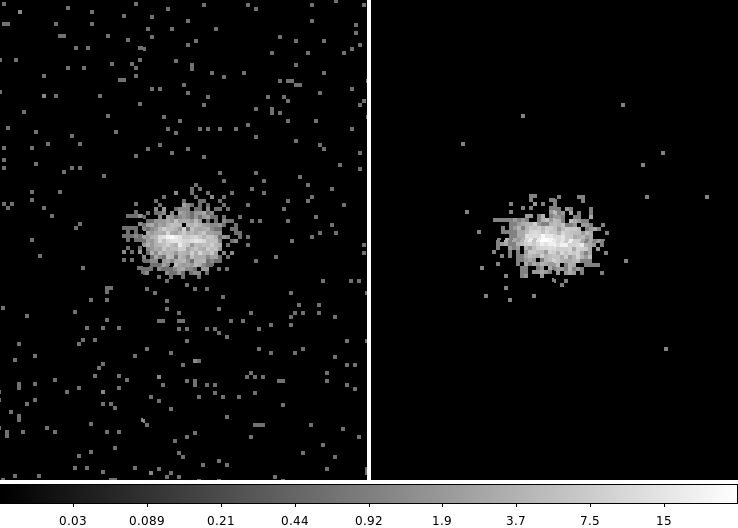

In [40]:
ds9 acisf00942_repro_evt2.fits \
  -pan to ${ra} ${dec} fk5 \
  -bin factor 1  \
  -scale log \
  marx_output_i0000.fits  -scale log \
  -pan to ${ra} ${dec} fk5 \
  -bin factor 1 -zoom 4 \
  -match frame wcs \
  -saveimage png ds9_04.png -quit

display < ds9_04.png 


## PSF Image


In [42]:
dmlist marx_output_i0000.fits blocks

 
--------------------------------------------------------------------------------
Dataset: marx_output_i0000.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: NULL                           Null        
Block    2: EVENTS                         Table        22 cols x 1575     rows
Block    3: GTI4                           Table         2 cols x 1        rows
Block    4: GTI5                           Table         2 cols x 1        rows
Block    5: GTI6                           Table         2 cols x 1        rows
Block    6: GTI7                           Table         2 cols x 1        rows
Block    7: GTI8                           Table         2 cols x 1        rows
Block    8: GTI9                           Table         2 cols x 1        rows
Block    9: MARX_PAR                    

In [43]:
dmlist marx_output_i0000.fits cols

 
--------------------------------------------------------------------------------
Columns for Table Block EVENTS
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   TIME                 s            Real8          362912400.0:362962709.1729696989 time since observation start
   2   CCD_ID                            Int2           0:9                  CCD id number
   3   NODE_ID                           Int2           -                    0-4
   4   EXPNO                             Int4           0:2147483647         Exposure number
   5   chip(CHIPX,CHIPY)    pixel        Int2           2:1023               CHIP X
   6   tdet(TDETX,TDETY)    pixel        Int4           2:8191               Detector X
   7   det(DETX,DETY)       pixel        Real4          0.50:     8192.50    Focal Plane X
   8   sky(X,Y)             pixel        Real4          0.50:     8192.50    sky X pixel
   9 

In [44]:
dmlist HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_i0000_rays.fits header | egrep 'SRC_(RA|DEC)'

0010 SRC_RA               184.237458333 [deg]            String       Input source Right Ascension
0011 SRC_DEC              37.7265805556 [deg]            String       Input source Declination


In [45]:
punlearn dmcoords
dmcoords acisf00942_repro_evt2.fits op=cel ra=184.237458333 dec=37.7265805556 celfmt=deg
pget dmcoords x y

4707.54001659262
3699.491929579939


### Create image

In [46]:
dmcopy "marx_output_i0000.fits[bin x=4451.54:4963.54:1,y=3443.49:3955.49:1]" psf_512_i0000.fits clob+


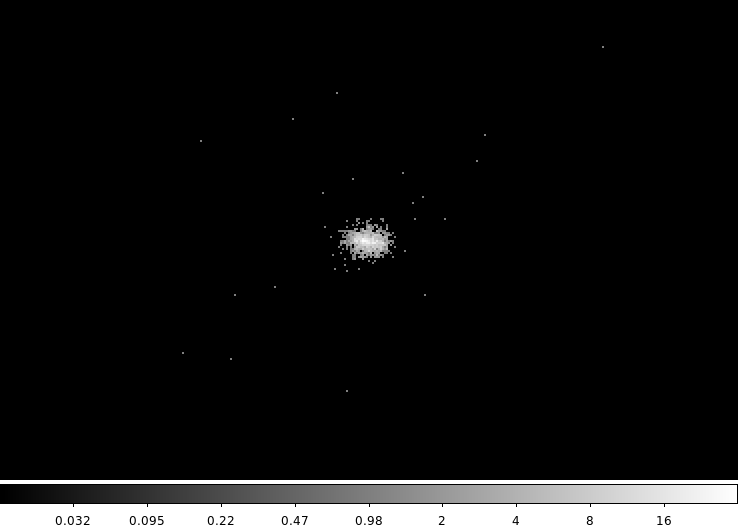

In [47]:
ds9 psf_512_i0000.fits -scale log -zoom 2 \
  -saveimage png ds9_05.png -quit

display < ds9_05.png

### Bin ray to match image

In [48]:
dmcopy "acisf00942_repro_evt2.fits[ccd_id=6]" ccd6_evt.fits  clob+

apply_fov_limits ccd6_evt.fits"[energy=400:6000]" ccd6_bin1.fits bin=1 clob+


Running: apply_fov_limits
  version: 12 September 2016
Observation: ObsId 942 - ACIS-235678
Using ccd_id=6 from ccd6_evt.fits[energy=400:6000]
Calculating FOV file using:
  Aspect solution pcadf075214790N004_asol1.fits
  Mask file       acisf00942_001N004_msk1.fits

The output image will have 1481 by 1480 pixels, pixel size of 0.492 arcsec,
    and cover x=3821.5:5302.5:1,y=2768.5:4248.5:1.

Created: ccd6_bin1.fits


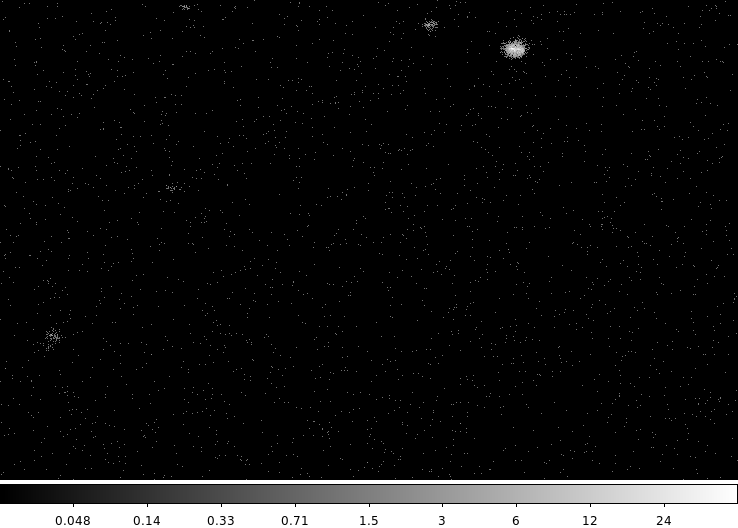

In [49]:
ds9 ccd6_bin1.fits -scale log -block 1 -saveimage ds9_06.png -quit
display < ds9_06.png

In [50]:
get_sky_limits ccd6_bin1.fits

Running: get_sky_limits
  version: 07 October 2016
Checking binning of image: ccd6_bin1.fits
  Image has 1481 x 1480 pixels
  Pixel size is 1.0 by 1.0
  Lower left (0.5,0.5) corner is x,y= 3821.5, 2768.5
  Upper right (1481.5,1480.5) corner is x,y= 5302.5, 4248.5
  DM filter is:
    x=3821.5:5302.5:#1481,y=2768.5:4248.5:#1480
  mkexpmap xygrid value is:
    3821.5:5302.5:#1481,2768.5:4248.5:#1480


In [51]:
dmcopy "marx_output_i0000.fits[bin x=3821.5:5302.5:#1481,y=2768.5:4248.5:#1480]" \
  psf_match_i0000.fits clob+

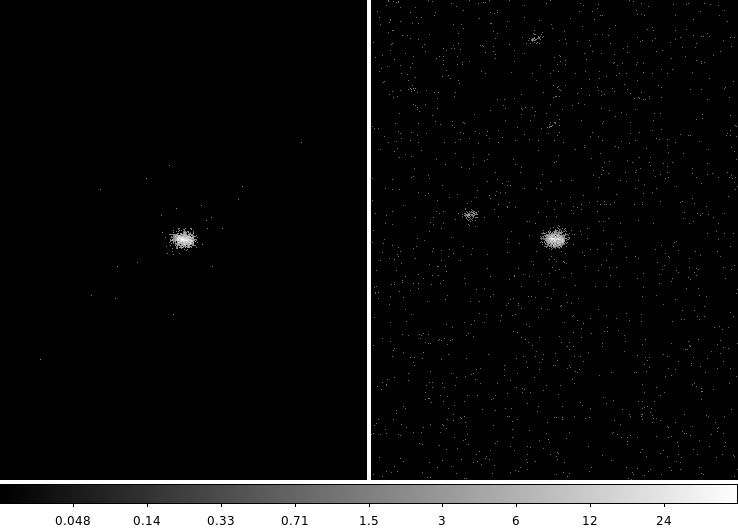

In [52]:
ds9 -scale log psf_match_i0000.fits ccd6_bin1.fits -pan to 4707 3699 physical \
  -match frames wcs \
  -saveimage png ds9_07.png -quit

display < ds9_07.png

### Create subpixel

In [53]:
 dmcopy "marx_output_i0000.fits[bin x=3820.5:5302.5:0.1,y=2768.5:4248.5:0.1]" psf_subpix.fits clob+

# DMCOPY (CIAO 4.9): WARNING: Creating large image: 439 MB. Current max set at 50 MB.
Increase maximum using [opt mem=n] or increase blocking to reduce size.


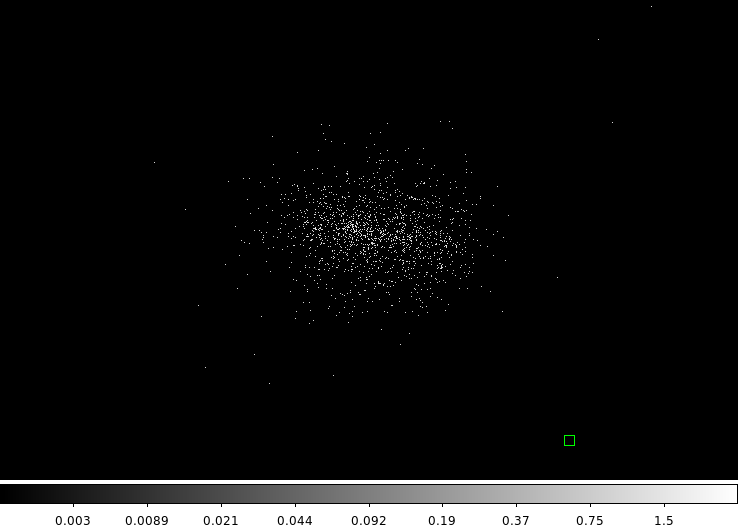

In [54]:
ds9  psf_subpix.fits -scale log  -pan to 4707 3699 physical \
  -regions command 'physical; box(4727,3679,1,1,0)' \
  -saveimage png ds9_08.png -quit

display < ds9_08.png


### Combine multiple realizations

In [55]:
for i in 0 1 2 3 4 5 6 7 8 9
do
  d=i000$i
  marx @@./marx OutputDir=marx_output_${d}.dir SAOSACFile=HRMA_ra184.23746_dec37.72658_${myid}.dat_dithered_${d}_rays.fits
  marx2fits --pixadj=EDSER marx_output_${d}.dir marx_output_${d}.fits
done


MARX version 5.3.2, Copyright (C) 2002-2016 Massachusetts Institute of Technology

	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/EKCHDOS06.rdb
Reading binary HRMA optical constants:
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/iridium.dat
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/corr_1.dat
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/corr_3.dat
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/corr_4.dat
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/corr_6.dat
Reading scattering tables
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/scat_p1_M.bin
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/scat_h1_M.bin
	/data/sdsreg/thread_output/CIAO4.9/prep_chart/marx-5.3.2/share/marx/data/hrma/scat_p3_M.bin
	/data/sdsreg/thread_output/C

In [56]:
dmmerge "marx_output_i00*.fits" marx_output.fits clob+
cts=`dmlist marx_output.fits counts`
dmimgcalc "marx_output.fits[bin x=3821.5:5302.5:#1481,y=2768.5:4248.5:#1480]" none norm_psf.fits op="imgout=img1/((float)${cts})" clob+

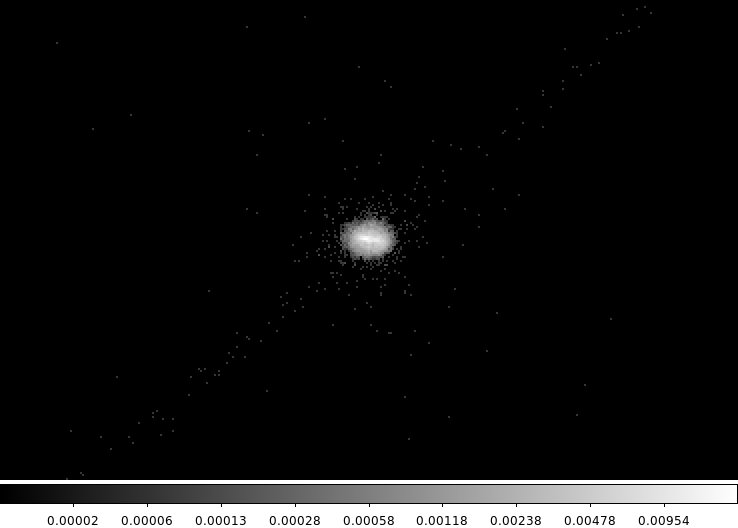

In [59]:
ds9 norm_psf.fits -scale log -pan to 4707 3699 physical \
  -zoom 2 \
  -saveimage png ds9_10.png -quit

display < ds9_10.png

In [58]:
dmlist "marx_output.fits" counts

15605   



# Cleanup

In [ ]:
/bin/rm -rf marx*dir/
/bin/rm -f ${myid}.dat
/bin/rm -f acisf*fits 
/bin/rm -f pcadf*fits pcad_asol.fits
/bin/rm -rf marx-5.3.2 
/bin/rm -rf 942
/bin/rm -f HRMA_*_dithered.tar.gz
/bin/rm -f ccd6_evt.fits
/bin/rm -f ccd6_bin1.fits
